In [14]:
import pandas as pd

df = pd.read_excel('Online Retail.xlsx')
df.head()

KeyboardInterrupt: 

## Basic Statistics

In [ ]:
# Shape and data types
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\n" + "="*60 + "\nInfo:")
df.info()

Shape: (541909, 8)

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
# Numeric summary statistics
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
# Categorical summary
print("Unique Invoices:", df['InvoiceNo'].nunique())
print("Unique Products (StockCode):", df['StockCode'].nunique())
print("Unique Customers:", df['CustomerID'].nunique())
print("Unique Countries:", df['Country'].nunique())
print("\nTop 5 Countries by transaction count:")
print(df['Country'].value_counts().head())

Unique Invoices: 25900
Unique Products (StockCode): 4070
Unique Customers: 4372
Unique Countries: 38

Top 5 Countries by transaction count:
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Name: count, dtype: int64


## Data Quality Observations

In [ ]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nPercentage missing:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Percentage missing:
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


In [ ]:
# Duplicates and data anomalies
print("Duplicate rows:", df.duplicated().sum())
print("\nNegative quantities:", (df['Quantity'] <= 0).sum())
print("Zero or negative unit prices:", (df['UnitPrice'] <= 0).sum())
print("\nRows with negative Quantity (returns/cancellations):")
print(df[df['Quantity'] <= 0][['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'InvoiceDate']].head(10))

Duplicate rows: 5268

Negative quantities: 10624
Zero or negative unit prices: 2517

Rows with negative Quantity (returns/cancellations):
    InvoiceNo StockCode  Quantity  UnitPrice         InvoiceDate
141   C536379         D        -1      27.50 2010-12-01 09:41:00
154   C536383    35004C        -1       4.65 2010-12-01 09:49:00
235   C536391     22556       -12       1.65 2010-12-01 10:24:00
236   C536391     21984       -24       0.29 2010-12-01 10:24:00
237   C536391     21983       -24       0.29 2010-12-01 10:24:00
238   C536391     21980       -24       0.29 2010-12-01 10:24:00
239   C536391     21484       -12       3.45 2010-12-01 10:24:00
240   C536391     22557       -12       1.65 2010-12-01 10:24:00
241   C536391     22553       -24       1.65 2010-12-01 10:24:00
939   C536506     22960        -6       4.25 2010-12-01 12:38:00


In [ ]:
# Empty/placeholder descriptions and InvoiceNo starting with 'C' (cancellations)
print("Empty descriptions:", df['Description'].isna().sum())

print("InvoiceNo starting with 'C' (cancellations):", df['InvoiceNo'].astype(str).str.startswith('C').sum())

Empty descriptions: 1454
InvoiceNo starting with 'C' (cancellations): 9288


## Data Cleaning

In [ ]:
# --- BEFORE CLEANING ---
print("BEFORE CLEANING")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"Rows: {len(df):,}")
print(f"Missing values: {df.isnull().sum().sum():,}")
print(f"  - CustomerID missing: {df['CustomerID'].isna().sum():,}")
print(f"  - Description missing: {df['Description'].isna().sum():,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Cancelled invoices (InvoiceNo starts with 'C'): {(df['InvoiceNo'].astype(str).str.startswith('C')).sum():,}")
print(f"Rows with Quantity <= 0: {(df['Quantity'] <= 0).sum():,}")
print(f"Rows with UnitPrice <= 0: {(df['UnitPrice'] <= 0).sum():,}")

BEFORE CLEANING
Shape: (541909, 8)
Rows: 541,909
Missing values: 136,534
  - CustomerID missing: 135,080
  - Description missing: 1,454
Duplicate rows: 5,268
Cancelled invoices (InvoiceNo starts with 'C'): 9,288
Rows with Quantity <= 0: 10,624
Rows with UnitPrice <= 0: 2,517


In [ ]:
# Create working copy
df_clean = df.copy()

# 1. Remove duplicates
df_clean = df_clean.drop_duplicates()

# 2. Remove rows with missing values (Description, CustomerID)
df_clean = df_clean.dropna(subset=['Description', 'CustomerID'])

# 3. Remove cancelled invoices (InvoiceNo starts with 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# 4. Remove returns/refunds (Quantity <= 0 or UnitPrice <= 0)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# 5. Create Revenue column
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [ ]:
# --- AFTER CLEANING ---
print("AFTER CLEANING")
print("=" * 50)
print(f"Shape: {df_clean.shape}")
print(f"Rows: {len(df_clean):,}")
print(f"Missing values: {df_clean.isnull().sum().sum():,}")
print(f"Duplicate rows: {df_clean.duplicated().sum():,}")
print(f"Rows with Quantity <= 0: {(df_clean['Quantity'] <= 0).sum():,}")
print(f"Rows with UnitPrice <= 0: {(df_clean['UnitPrice'] <= 0).sum():,}")
print(f"\nRows removed: {len(df) - len(df_clean):,} ({100 * (1 - len(df_clean)/len(df)):.1f}%)")

AFTER CLEANING
Shape: (392692, 9)
Rows: 392,692
Missing values: 0
Duplicate rows: 0
Rows with Quantity <= 0: 0
Rows with UnitPrice <= 0: 0

Rows removed: 149,217 (27.5%)


In [ ]:
# Summary comparison
comparison = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Missing values', 'Duplicates'],
    'Before': [len(df), df.shape[1], df.isnull().sum().sum(), df.duplicated().sum()],
    'After': [len(df_clean), df_clean.shape[1], df_clean.isnull().sum().sum(), df_clean.duplicated().sum()]
})
comparison['Change'] = comparison['After'] - comparison['Before']
print(comparison.to_string(index=False))

        Metric  Before  After  Change
          Rows  541909 392692 -149217
       Columns       8      9       1
Missing values  136534      0 -136534
    Duplicates    5268      0   -5268


In [ ]:
df_clean.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08


## Sales & Revenue Analysis

In [28]:
import matplotlib.pyplot as plt

# Set date as index for time-based aggregation
df_clean['Date'] = pd.to_datetime(df_clean['InvoiceDate']).dt.date

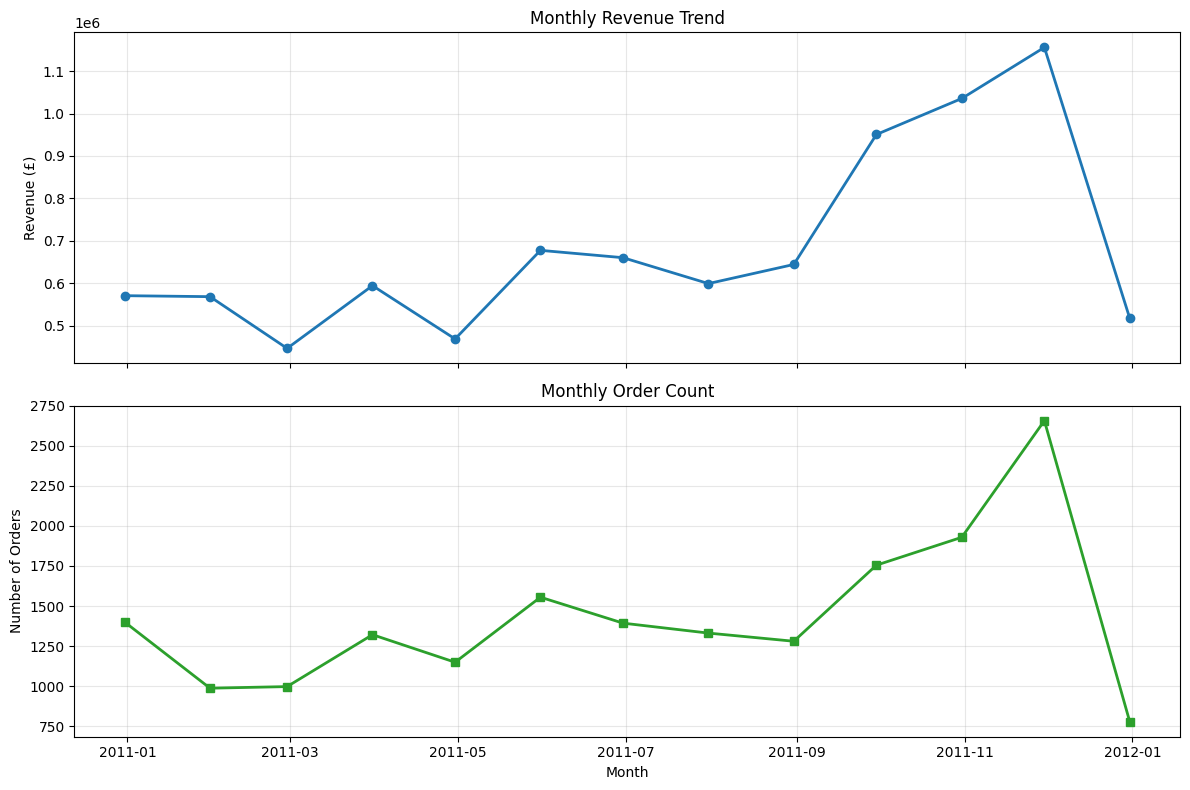

In [29]:
# --- 1. Sales & Revenue Trends Over Time (Monthly) ---
monthly = df_clean.groupby(pd.Grouper(key='InvoiceDate', freq='ME')).agg(
    Revenue=('Revenue', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    LineItems=('InvoiceNo', 'count')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(monthly['InvoiceDate'], monthly['Revenue'], marker='o', linewidth=2)
axes[0].set_ylabel('Revenue (£)')
axes[0].set_title('Monthly Revenue Trend')
axes[0].grid(True, alpha=0.3)
axes[1].plot(monthly['InvoiceDate'], monthly['Orders'], marker='s', color='tab:green', linewidth=2)
axes[1].set_ylabel('Number of Orders')
axes[1].set_xlabel('Month')
axes[1].set_title('Monthly Order Count')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

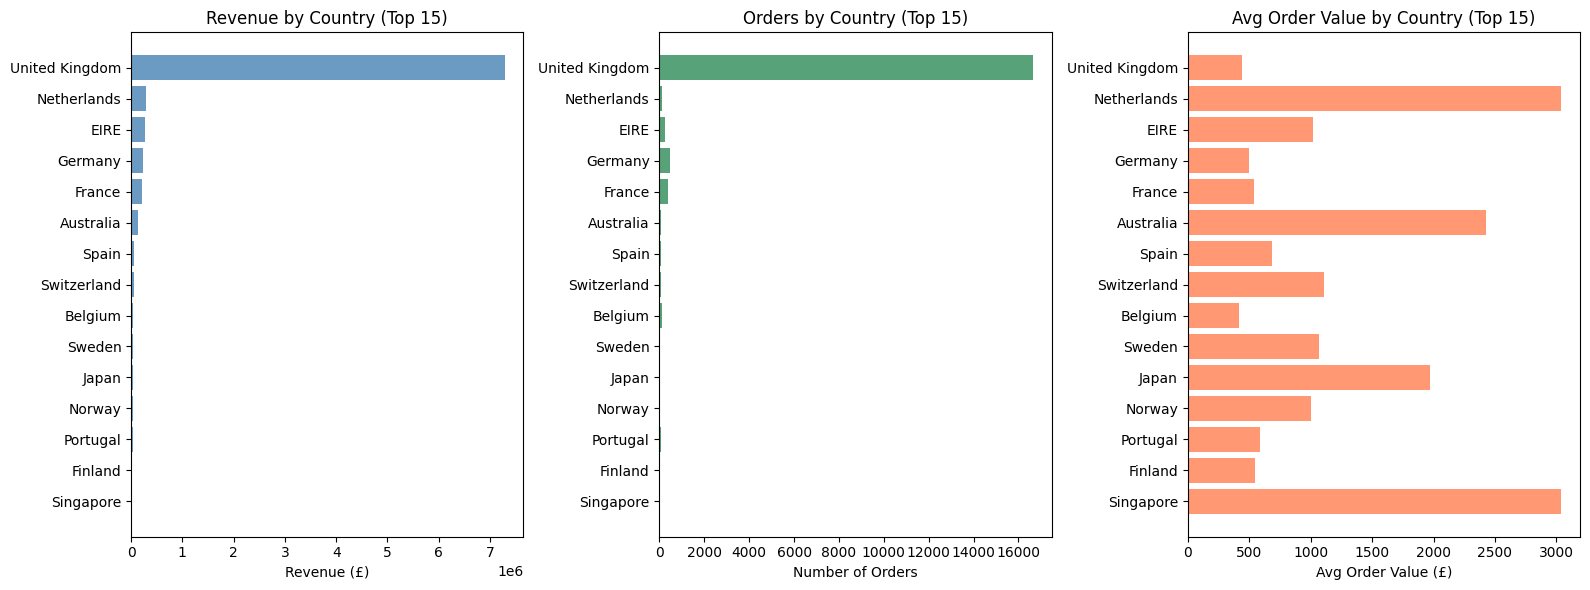

In [30]:
# --- 2. Geographic Distribution ---
geo = df_clean.groupby('Country').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    LineItems=('InvoiceNo', 'count')
).reset_index()
geo['AOV'] = geo['Revenue'] / geo['Orders']
geo_top = geo.nlargest(15, 'Revenue').sort_values('Revenue', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].barh(geo_top['Country'], geo_top['Revenue'], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Revenue (£)')
axes[0].set_title('Revenue by Country (Top 15)')
axes[1].barh(geo_top['Country'], geo_top['Orders'], color='seagreen', alpha=0.8)
axes[1].set_xlabel('Number of Orders')
axes[1].set_title('Orders by Country (Top 15)')
axes[2].barh(geo_top['Country'], geo_top['AOV'], color='coral', alpha=0.8)
axes[2].set_xlabel('Avg Order Value (£)')
axes[2].set_title('Avg Order Value by Country (Top 15)')
plt.tight_layout()
plt.show()

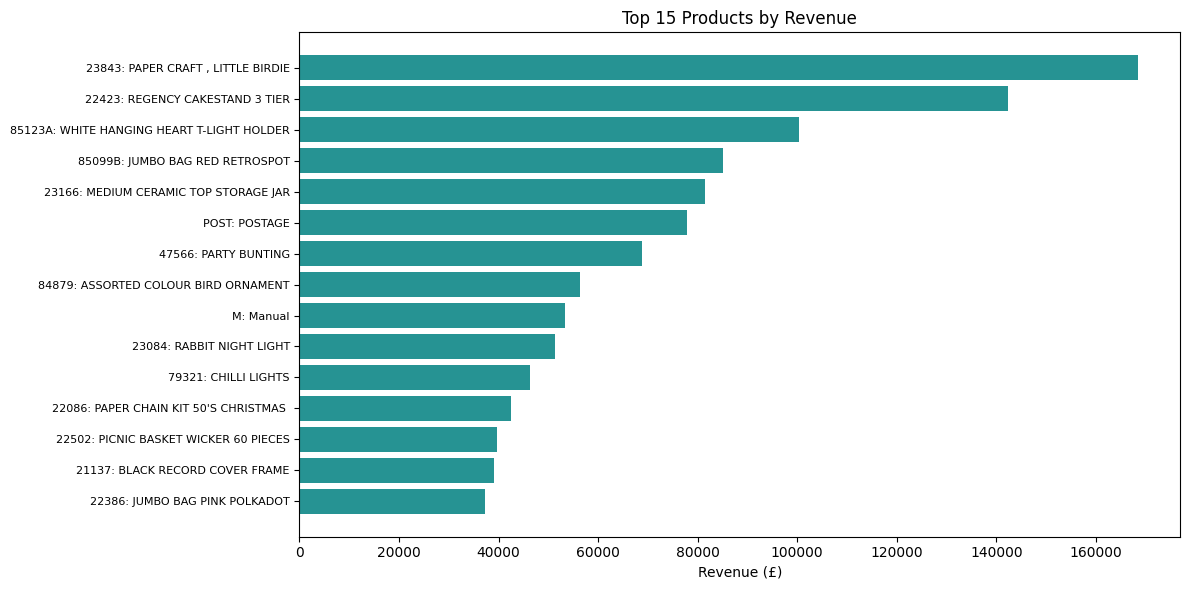

In [33]:
# --- 3. Top Performing Products ---
import pandas as pd
import matplotlib.pyplot as plt

required_cols = ['StockCode', 'Description', 'Quantity', 'InvoiceNo']

for col in required_cols:
    if col not in df_clean.columns:
        raise ValueError(f"Missing required column: {col}")

if 'Revenue' not in df_clean.columns:
    if 'UnitPrice' not in df_clean.columns:
        raise ValueError("Revenue column not found and UnitPrice missing.")
    df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean['Quantity'] = pd.to_numeric(df_clean['Quantity'], errors='coerce')
df_clean['Revenue'] = pd.to_numeric(df_clean['Revenue'], errors='coerce')
df_clean['StockCode'] = df_clean['StockCode'].astype(str)
df_clean['Description'] = df_clean['Description'].fillna('').astype(str)

df_clean = df_clean.dropna(subset=['Revenue'])

top_products = (
    df_clean
    .groupby(['StockCode', 'Description'], as_index=False)
    .agg(
        Revenue=('Revenue', 'sum'),
        Quantity=('Quantity', 'sum'),
        Orders=('InvoiceNo', 'nunique')
    )
    .nlargest(15, 'Revenue')
)

top_products['Product'] = (
    top_products['StockCode'] + ': ' +
    top_products['Description'].str[:40]
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(
    top_products['Product'][::-1],
    top_products['Revenue'][::-1],
    color='teal',
    alpha=0.85
)

ax.set_xlabel('Revenue (£)')
ax.set_title('Top 15 Products by Revenue')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

Average Order Value (AOV): £479.56
Median Order Value: £302.57
Min Order: £0.38 | Max Order: £168,469.60


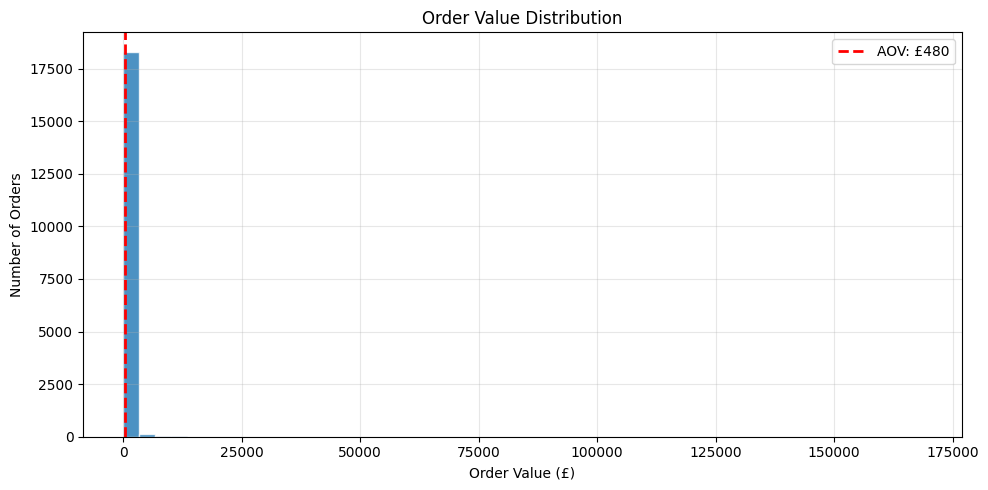

In [32]:
# --- 4. Average Order Value ---
order_totals = df_clean.groupby('InvoiceNo')['Revenue'].sum()
aov = order_totals.mean()
aov_median = order_totals.median()
print(f"Average Order Value (AOV): £{aov:,.2f}")
print(f"Median Order Value: £{aov_median:,.2f}")
print(f"Min Order: £{order_totals.min():,.2f} | Max Order: £{order_totals.max():,.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(order_totals, bins=50, edgecolor='white', alpha=0.8)
ax.axvline(aov, color='red', linestyle='--', linewidth=2, label=f'AOV: £{aov:,.0f}')
ax.set_xlabel('Order Value (£)')
ax.set_ylabel('Number of Orders')
ax.set_title('Order Value Distribution')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Top Product Categories by Revenue

*Note: Dataset has no category column. Categories are derived from the last word of the Description (product type: BAG, HOLDER, LANTERN, etc.).*

In [34]:
# Derive category from last word of Description (product type)
df_clean['Category'] = df_clean['Description'].str.strip().str.split().str[-1].str.upper()

# Aggregate revenue by category
cat_revenue = df_clean.groupby('Category')['Revenue'].agg(['sum', 'count']).reset_index()
cat_revenue = cat_revenue.rename(columns={'sum': 'Revenue', 'count': 'LineItems'})
total_rev = cat_revenue['Revenue'].sum()
cat_revenue['Pct_Revenue'] = 100 * cat_revenue['Revenue'] / total_rev
cat_revenue = cat_revenue.sort_values('Revenue', ascending=False).reset_index(drop=True)

print("Top 20 product categories by revenue:")
print(cat_revenue.head(20).to_string(index=False))

Top 20 product categories by revenue:
 Category   Revenue  LineItems  Pct_Revenue
   DESIGN 392480.16      20172     4.416236
   HOLDER 337566.84      10410     3.798345
RETROSPOT 274627.91       9585     3.090148
      BOX 207580.64       9382     2.335724
     SIGN 200551.43       9338     2.256630
  BUNTING 190135.02       4967     2.139423
   BIRDIE 168469.60          1     1.895641
     TIER 154076.82       2183     1.733692
CHRISTMAS 152508.58       6164     1.716046
   BOTTLE 136009.03       5426     1.530391
      SET 133050.48       6294     1.497101
    CASES 132510.74       8529     1.491028
      JAR 105970.88       1258     1.192398
      RED  96952.62       3653     1.090923
      BAG  95913.12       6237     1.079227
  POSTAGE  89710.32       1115     1.009432
    LARGE  88059.61       3664     0.990858
     PINK  83211.69       3685     0.936308
   FINISH  80277.08       2373     0.903288
      MUG  78786.27       4253     0.886513


In [35]:
# Cumulative revenue share (80/20 rule)
cat_revenue['CumPct'] = cat_revenue['Pct_Revenue'].cumsum()
print("\nCategories contributing to 80% of revenue:")
top_80 = cat_revenue[cat_revenue['CumPct'] <= 80]
print(f"  Number of categories: {len(top_80)} out of {len(cat_revenue)}")
print(top_80[['Category', 'Revenue', 'Pct_Revenue', 'CumPct']].to_string(index=False))


Categories contributing to 80% of revenue:
  Number of categories: 148 out of 858
   Category   Revenue  Pct_Revenue    CumPct
     DESIGN 392480.16     4.416236  4.416236
     HOLDER 337566.84     3.798345  8.214581
  RETROSPOT 274627.91     3.090148 11.304729
        BOX 207580.64     2.335724 13.640453
       SIGN 200551.43     2.256630 15.897083
    BUNTING 190135.02     2.139423 18.036506
     BIRDIE 168469.60     1.895641 19.932148
       TIER 154076.82     1.733692 21.665840
  CHRISTMAS 152508.58     1.716046 23.381885
     BOTTLE 136009.03     1.530391 24.912276
        SET 133050.48     1.497101 26.409377
      CASES 132510.74     1.491028 27.900405
        JAR 105970.88     1.192398 29.092802
        RED  96952.62     1.090923 30.183726
        BAG  95913.12     1.079227 31.262952
    POSTAGE  89710.32     1.009432 32.272384
      LARGE  88059.61     0.990858 33.263242
       PINK  83211.69     0.936308 34.199550
     FINISH  80277.08     0.903288 35.102838
        MUG  7878

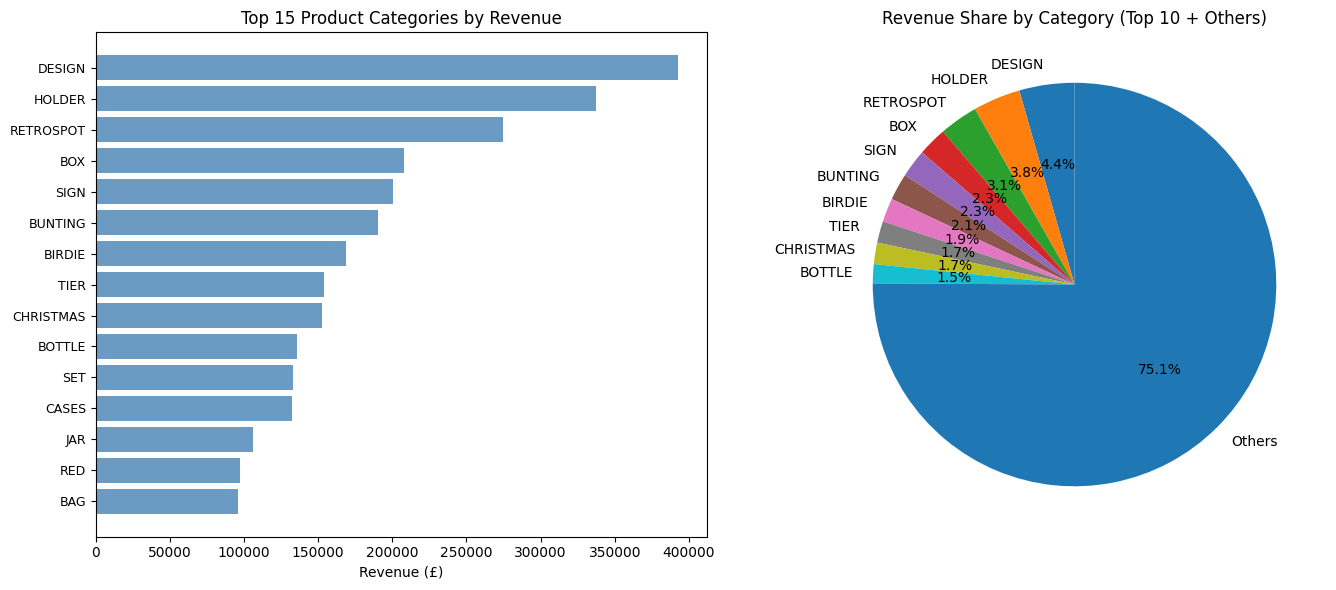

In [36]:
# Plot: top 15 categories by revenue
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top15 = cat_revenue.head(15)

axes[0].barh(top15['Category'][::-1], top15['Revenue'][::-1], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Revenue (£)')
axes[0].set_title('Top 15 Product Categories by Revenue')
axes[0].tick_params(axis='y', labelsize=9)

# Pie chart for top 10 + Others
top10_rev = cat_revenue.head(10)
others_rev = cat_revenue.iloc[10:]['Revenue'].sum()
pie_data = pd.concat([
    top10_rev[['Category', 'Revenue']],
    pd.DataFrame([{'Category': 'Others', 'Revenue': others_rev}])
])
axes[1].pie(pie_data['Revenue'], labels=pie_data['Category'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Revenue Share by Category (Top 10 + Others)')
plt.tight_layout()
plt.show()